## 1. Data Loading and Initial Preprocessing

### 1.1 Library Imports and Data Loading
To begin the analysis, we import the necessary libraries for data manipulation, statistical testing, and time series modeling. 

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from scipy.special import inv_boxcox

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.holtwinters import Holt,ExponentialSmoothing
from statsmodels.tsa.seasonal import  seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
np.random.seed(42)

We then load the daily minimum temperatures dataset, ensuring that the `Date` column is correctly parsed as datetime objects to facilitate time series operations. For ease of use throughout the notebook, the target variable is renamed to `min_temp`.

In [190]:
df = pd.read_csv("Dataset 3_ daily-minimum-temperatures-in-me.csv", parse_dates=["Date"])
df.rename(columns={"Daily minimum temperatures": "min_temp"}, inplace=True)
df.head(10)

,Date,min_temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
5,1981-01-06,15.8
6,1981-01-07,15.8
7,1981-01-08,17.4
8,1981-01-09,21.8
9,1981-01-10,20


## 1.2 Data Quality Checks
A robust time series analysis requires a continuous and uniform sequence of data points. To ensure data integrity, we perform the following checks:
*   **Duplicate Dates:** We verified that there are no duplicate date entries in the dataset.

In [191]:
df["Date"].duplicated().sum()

np.int64(0)

*   **Continuity:** By generating an expected continuous date range from the minimum to the maximum date, we compared it against our actual timestamps. We observed two missing timestamps: **1984-12-31** and **1988-12-31**.

In [192]:
timestamps = pd.to_datetime(df["Date"])
    
# Generate the expected continuous range
expected_range = pd.date_range(start=timestamps.min(), end=timestamps.max(), freq="D")
    
# Find the difference between expected and actual
missing_timestamps = expected_range.difference(timestamps).tolist()
missing_timestamps

[Timestamp('1984-12-31 00:00:00'), Timestamp('1988-12-31 00:00:00')]

*   **Missing Values (NaNs):** A standard check reveals no immediate `NaN` values in the dataset 

In [193]:
df.isna().sum()

Date        0
min_temp    0
dtype: int64

The data is then sorted chronologically to maintain the correct temporal order

In [194]:
df.sort_values(by="Date", ascending=True, inplace=True)

### 1.3 Data Cleaning
During exploration, we identified anomalous string entries in the `min_temp` column (e.g., `?0.2`, `?0.8`). 
*    These characters likely represent measurement flags or data entry errors. 
*    Mathematical models like ARIMA and exponential smoothing strictly require numeric inputs. Leaving these characters in would cause type errors and model failure.
*    We used regular expressions to strip any non-numeric characters (except decimals and negative signs) and successfully cast the entire column to a `float64` data type

In [195]:
bad_data = df[df["min_temp"].astype(str).str.contains(r'[^\d\.\-]', regex=True)]

print("Here are the messy rows:")
print(bad_data["min_temp"].head())

Here are the messy rows:
565     ?0.2
566     ?0.8
1290    ?0.1
Name: min_temp, dtype: object


In [196]:
df["min_temp"] = df["min_temp"].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
df["min_temp"] = df["min_temp"].astype("float64")

### 1.4 Outlier Detection and Treatment
We utilized the Interquartile Range (IQR) method to identify extreme temperature values.
*    The analysis flagged 28 outliers, making up approximately 0.76% of the dataset. The values outside the acceptable bounds ($0.3^\circ\text{C}$ to $21.9^\circ\text{C}$) were identified.
*    Extreme outliers can heavily skew the calculation of rolling statistics, manipulate the ACF/PACF plots, and artificially inflate the error metrics of forecasting models. 
*    Rather than dropping these rows (which would create more gaps in our time series), we **clipped** the outliers to our calculated lower and upper bounds. This safely limits their extreme impact while preserving the dataset's structural continuity.

In [197]:
summary = []
# Select only numeric columns

Q1 = df["min_temp"].quantile(0.26)
Q3 = df["min_temp"].quantile(0.74)
# Calculate the Interquartile Range
IQR = Q3 - Q1
# Define the lower and upper bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify rows that fall outside the bounds
outliers = df[(df["min_temp"] < lower_bound) | (df["min_temp"] > upper_bound)]
# Append the findings to the summary list
summary.append({
    "Outlier_Count": len(outliers),
    "Outlier_Pct (%)": (len(outliers) / len(df)) * 100,
    "Lower_Bound": lower_bound,
    "Upper_Bound": upper_bound,
    "Min_Value" : df["min_temp"].min(),
    "Max_Value" : df["min_temp"].max()
})
display(pd.DataFrame(summary))

df["min_temp"] = df["min_temp"].clip(lower=lower_bound, upper=upper_bound)

,Outlier_Count,Outlier_Pct (%),Lower_Bound,Upper_Bound,Min_Value,Max_Value
0,28,0.767123,0.3,21.9,0.0,26.3


In [198]:
df.describe()

,Date,min_temp
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.168986
min,1981-01-01 00:00:00,0.300000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,21.900000
std,NaN,4.044535


## 2. Exploratory Data Analysis (EDA)

### 2.1 Yearly Seasonality Visualization
To understand the underlying patterns in the time series, we visualize the data broken down by individual years.
*    By extracting the `Year` and `DayOfYear`, we generate stacked subplots sharing the same 1–365 x-axis.
*    This overlay method makes it easy to visually confirm consistent seasonal cycles across different years. We can observe the predictable temperature dips during the middle of the year (winter) and peaks at the beginning and end (summer).



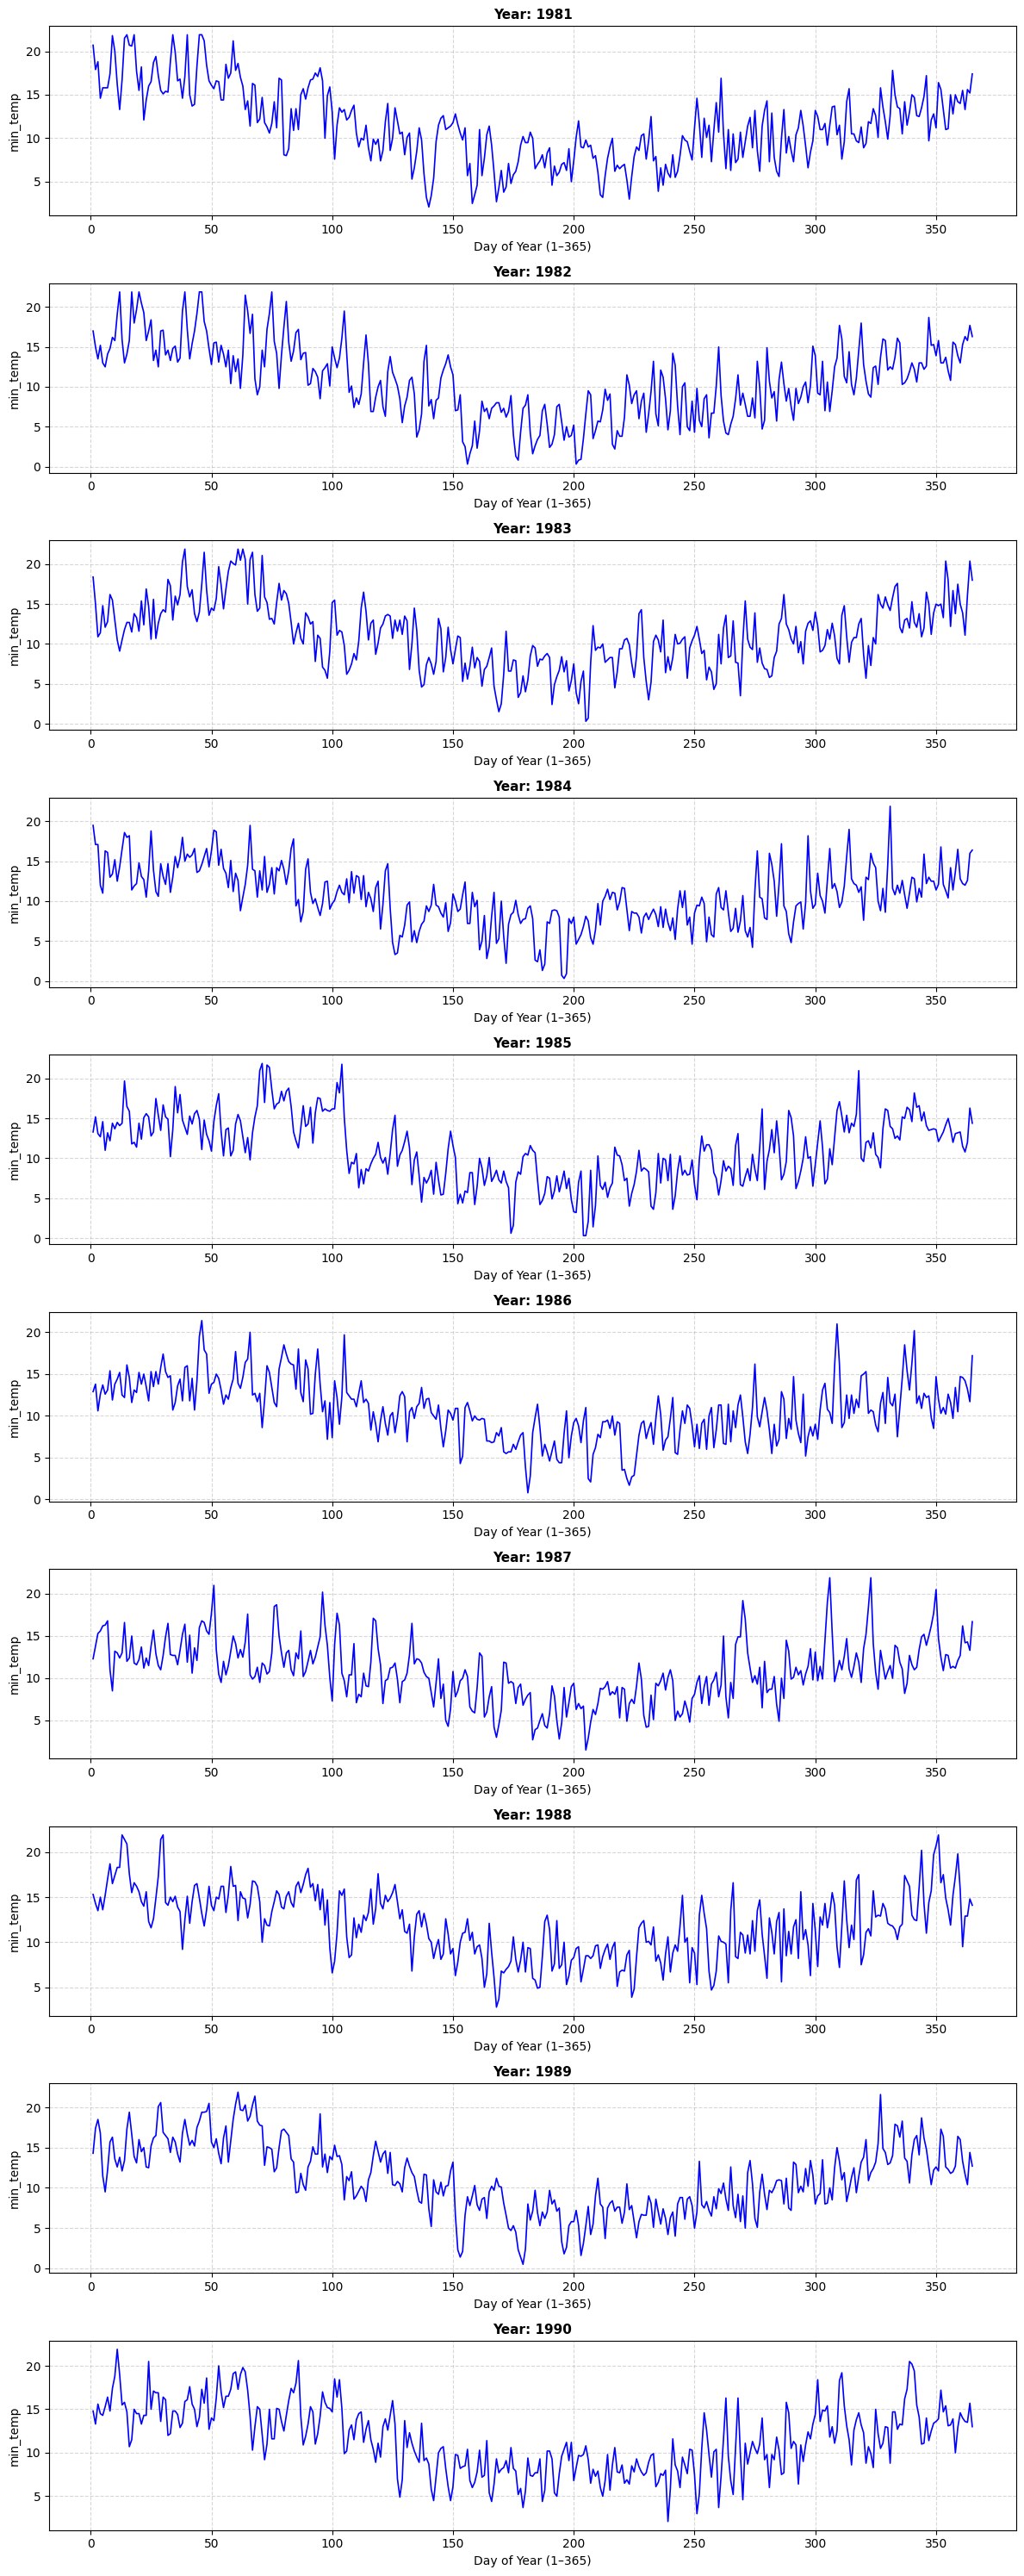

In [199]:
def plot_yearly_subplots(df, date_col, value_col):

    df_clean = df.copy()

    # 1. Format dates and extract year & day-of-year
    df_clean["Year"] = df_clean[date_col].dt.year
    df_clean["DayOfYear"] = df_clean[date_col].dt.dayofyear

    years = sorted(df_clean["Year"].unique())
    num_years = len(years)

    # 2. Dynamically calculate grid rows based on number of years

    # 3. Initialize subplots with a shared Y-axis for easy comparison
    fig, axes = plt.subplots(10, 1, figsize=(12, 30))

    # Flatten the axes array to simplify iteration regardless of grid size
    axes_flat = axes.flatten() if num_years > 1 else [axes]

    # 4. Plot each year on its respective axis
    for i, year in enumerate(years):
        ax = axes_flat[i]
        df_year = df_clean[df_clean["Year"] == year]

        # Plot DayOfYear on the X-axis so all yearly shapes align on scale
        ax.plot(
            df_year["DayOfYear"],
            df_year[value_col],
            color="blue",
            linewidth=1.2,
        )
        ax.set_title(f"Year: {year}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Day of Year (1–365)")
        ax.set_ylabel(value_col)
        ax.grid(True, linestyle="--", alpha=0.5)

    # 5. Remove any unused blank subplots at the end of the grid
    for j in range(num_years, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()


# Example Usage:
plot_yearly_subplots(df, date_col='Date', value_col='min_temp')

### 2.2 Assessing Stationarity (Mean and Variance)
Many forecasting models, including ARIMA, assume that the time series is weakly stationary, meaning its mean and variance do not change over time. To test this, we split the data into 10 sequential chunks and calculated local statistics.
*    While the global variance is $16.3583$, the variance across the 10 splits fluctuates significantly, ranging from a low of $12.9370$ to a high of $22.2428$.
*    This high fluctuation indicates non-constant variance. Because the variance changes over time, the raw time series is not strictly stationary and requires transformation before modeling.


In [200]:
global_mean = df["min_temp"].mean()
global_variance = df["min_temp"].var()
print(f"Global Mean: {global_mean:.4f}")
print(f"Global var: {global_variance:.4f}\n")

splits = np.array_split(df["min_temp"], 10)
for i, split in enumerate(splits):
    split_mean = split.mean()
    split_var = split.var()
    print(f"Split {i+1} | Mean: {split_mean:.4f} | Variance: {split_var:.4f}")

Global Mean: 11.1690
Global var: 16.3583

Split 1 | Mean: 11.4915 | Variance: 18.2003
Split 2 | Mean: 10.7515 | Variance: 22.2428
Split 3 | Mean: 11.1858 | Variance: 17.4614
Split 4 | Mean: 10.5858 | Variance: 13.7660
Split 5 | Mean: 11.1362 | Variance: 17.1011
Split 6 | Mean: 10.8033 | Variance: 13.0387
Split 7 | Mean: 10.8441 | Variance: 12.9370
Split 8 | Mean: 11.9611 | Variance: 13.8156
Split 9 | Mean: 11.2616 | Variance: 18.7737
Split 10 | Mean: 11.6690 | Variance: 14.9006


### 2.3 Variance Stabilization via Log Transformation
To address the non-constant variance identified above, we must transform the data to stabilize its spread.
*    We apply a natural log transformation (`np.log`). Before doing so, we shift all temperatures by $+1$ (`df["min_temp"] + 1`) to strictly ensure all values are positive and avoid mathematical errors when computing the logarithm.
*    We recalculated the chunked statistics on the new `Transform` column. The local variances are now tightly constrained between $0.0970$ and $0.2463$, with a global variance of $0.1507$.
*    The log transformation successfully dampened the extreme fluctuations in variance. By stabilizing the variance, we have brought the dataset much closer to stationarity, which is a critical prerequisite for building reliable ARIMA/SARIMA models.

In [201]:
df["temp_shifted"] = df["min_temp"] + 1

df["Transform"] = np.log(df["temp_shifted"])

In [202]:
global_mean = df["Transform"].mean()
global_variance = df["Transform"].var()
print(f"Global Mean: {global_mean:.4f}")
print(f"Global var: {global_variance:.4f}\n")

splits = np.array_split(df["Transform"], 10)
for i, split in enumerate(splits):
    split_mean = split.mean()
    split_var = split.var()
    print(f"Split {i+1} | Mean: {split_mean:.4f} | Variance: {split_var:.4f}")

Global Mean: 2.4333
Global var: 0.1507

Split 1 | Mean: 2.4608 | Variance: 0.1395
Split 2 | Mean: 2.3616 | Variance: 0.2463
Split 3 | Mean: 2.4309 | Variance: 0.1603
Split 4 | Mean: 2.3865 | Variance: 0.1507
Split 5 | Mean: 2.4242 | Variance: 0.1724
Split 6 | Mean: 2.4133 | Variance: 0.1254
Split 7 | Mean: 2.4201 | Variance: 0.1135
Split 8 | Mean: 2.5168 | Variance: 0.0970
Split 9 | Mean: 2.4310 | Variance: 0.1757
Split 10 | Mean: 2.4878 | Variance: 0.1110


### 2.4 Trend Visualization (Rolling Mean)
To filter out high-frequency daily noise and reveal the underlying local trend, we apply a rolling mean to the original data.
*   We calculate a moving average (`rolling(window=15).mean()`) over the transformed time series. 
*   This preliminary smoothing technique provides a clear visual baseline of the structural data and low-frequency changes before we apply more complex forecasting models.

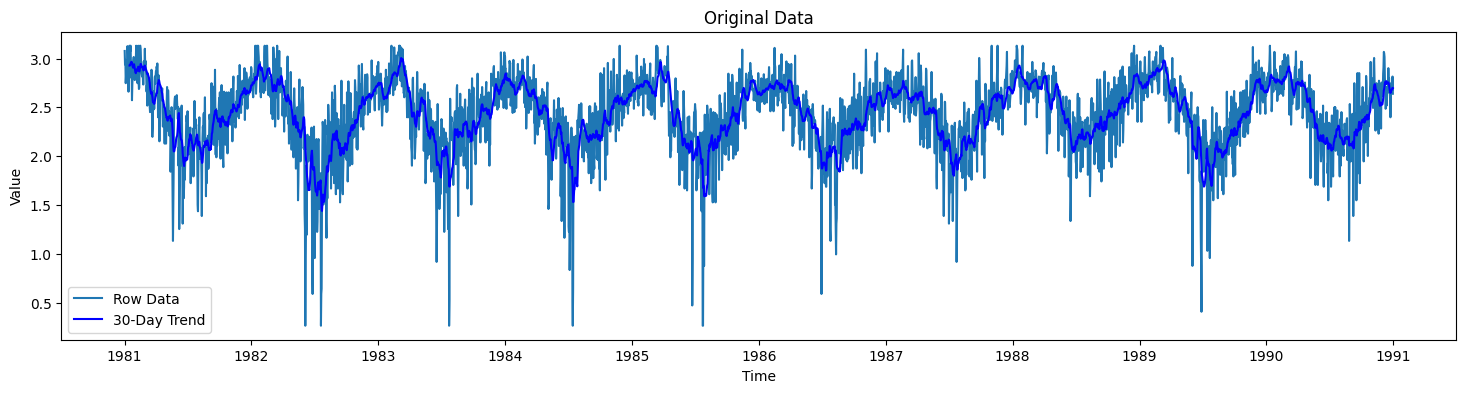

In [203]:
plt.figure(figsize=(18, 4))
plt.plot(df["Date"],df["Transform"],label = "Row Data")
plt.plot(df["Date"], df['Transform'].rolling(window=15).mean(), color="blue", label="30-Day Trend")
plt.title("Original Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

### 2.5 Temporal Dependence: ACF and PACF Analysis
To assess temporal dependence and inform our modeling strategy, we examine the Autocorrelation and Partial Autocorrelation functions.
*    We generate ACF and PACF plots up to 40 lags using `statsmodels` to evaluate how the current values correlate with past observations.
*    The ACF helps identify Moving Average (MA) components, slow-decaying trends, and seasonal cycles. The PACF isolates the direct correlation at specific lags by removing intermediate influences, which is critical for determining Autoregressive (AR) terms.

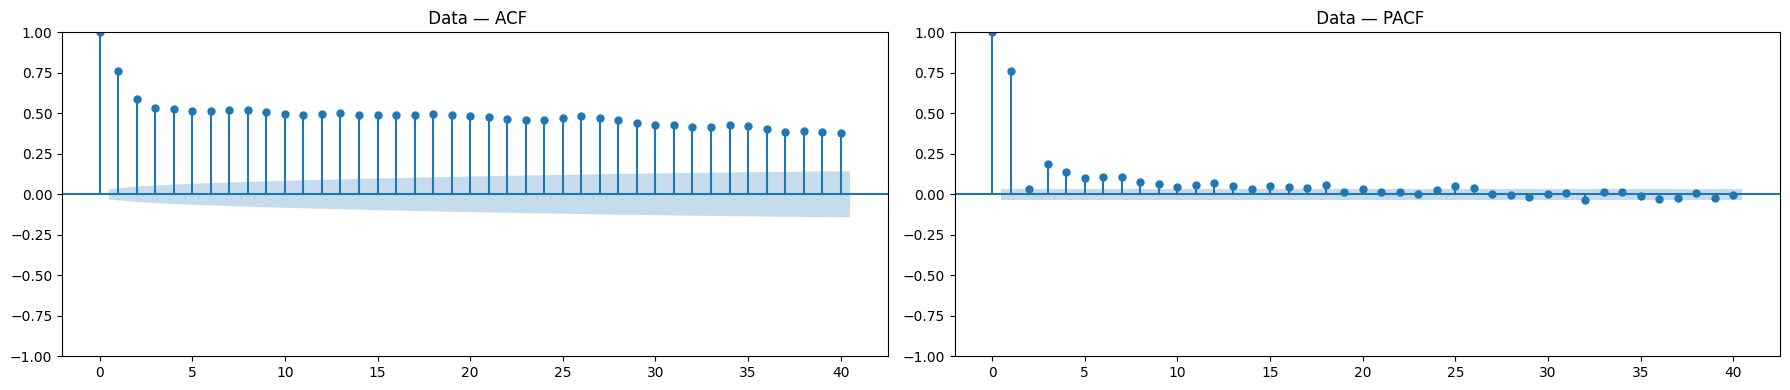

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    
plot_acf(
    df["Transform"],
    lags=40,
    ax=axes[0]
)

plot_pacf(
    df["Transform"],
    lags=40,
    ax=axes[1],
    method="ywm"
)

axes[0].set_title(" Data — ACF")
axes[1].set_title(" Data — PACF")

plt.tight_layout()
plt.show()

### 2.6 Smoothing Techniques: Holt's Linear Trend
We establish a preliminary baseline forecasting approach by applying Holt's Linear Trend method.
*    We fit the `Holt()` model to our transformed time series to explicitly capture the linear trend via exponential smoothing.
*    Evaluating a trend-only model allows us to assess how accurately the data's general trend is captured before we introduce explicit seasonal complexity.

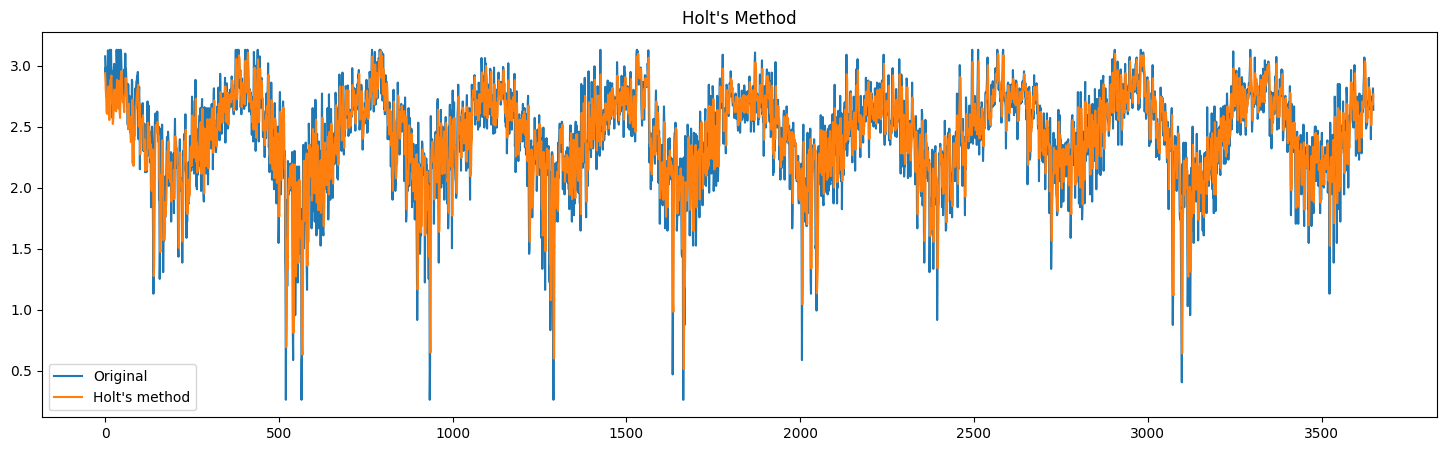

In [205]:
holt_model = Holt(df["Transform"]).fit()

plt.figure(figsize=(18, 5))

plt.plot(df["Transform"], label="Original")
plt.plot(holt_model.fittedvalues,label="Holt's method")

plt.title("Holt's Method")
plt.legend()
plt.show()

### 2.7 Smoothing Techniques: Holt-Winters Exponential Smoothing
Building upon Holt's method, we upgrade our model to account for the repeating seasonal cycles observed during our exploratory analysis.
*    We fit an `ExponentialSmoothing` model, explicitly specifying an `additive` trend, `additive` seasonality, and a `seasonal_periods` of 365 days.
*    An additive seasonal model is appropriate here because the amplitude of the annual seasonal fluctuations remains relatively constant across the series, rather than scaling multiplicatively with the overall level.

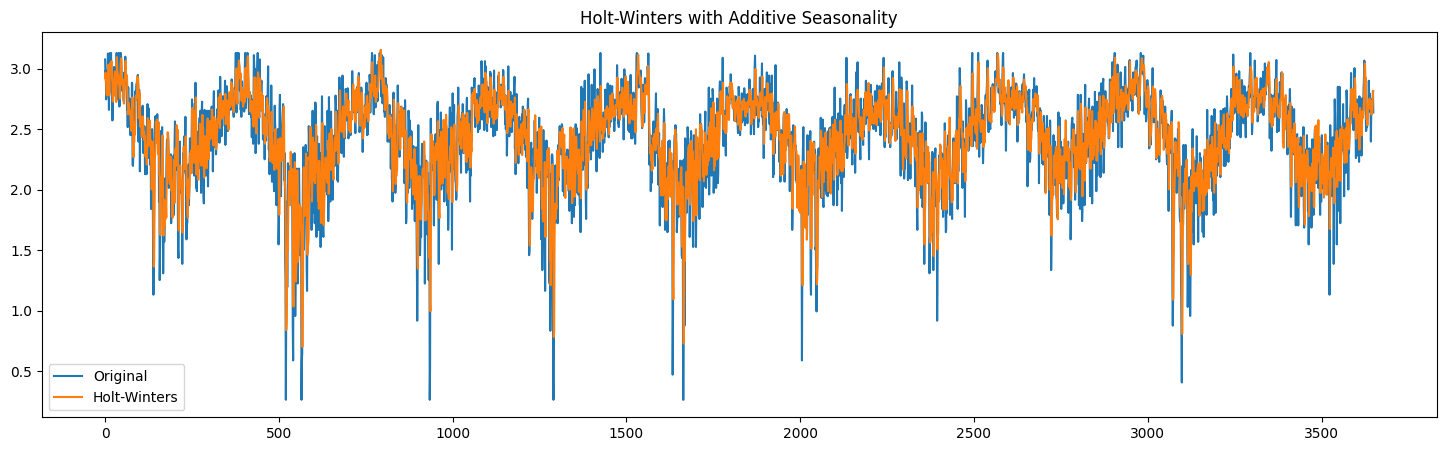

In [206]:
plt.figure(figsize=(18, 5))

hw_additive = ExponentialSmoothing(
    df["Transform"],
    trend="add",
    seasonal="add",
    seasonal_periods=365
).fit()

plt.plot(df["Transform"], label="Original")
plt.plot(
    hw_additive.fittedvalues,
    label="Holt-Winters"
)

plt.title("Holt-Winters with Additive Seasonality")
plt.legend()
plt.show()

### 2.8 Additive Time Series Decomposition
To further break down the structure of our transformed time series, we decouple the overlapping temporal patterns.
*    We utilize `seasonal_decompose` from `statsmodels` with an `additive` model and a `period` of 365 days.
*    This technique explicitly separates the long-term (Trend) and the repeating annual cycle (Seasonality) from the irregular fluctuations (Residuals).

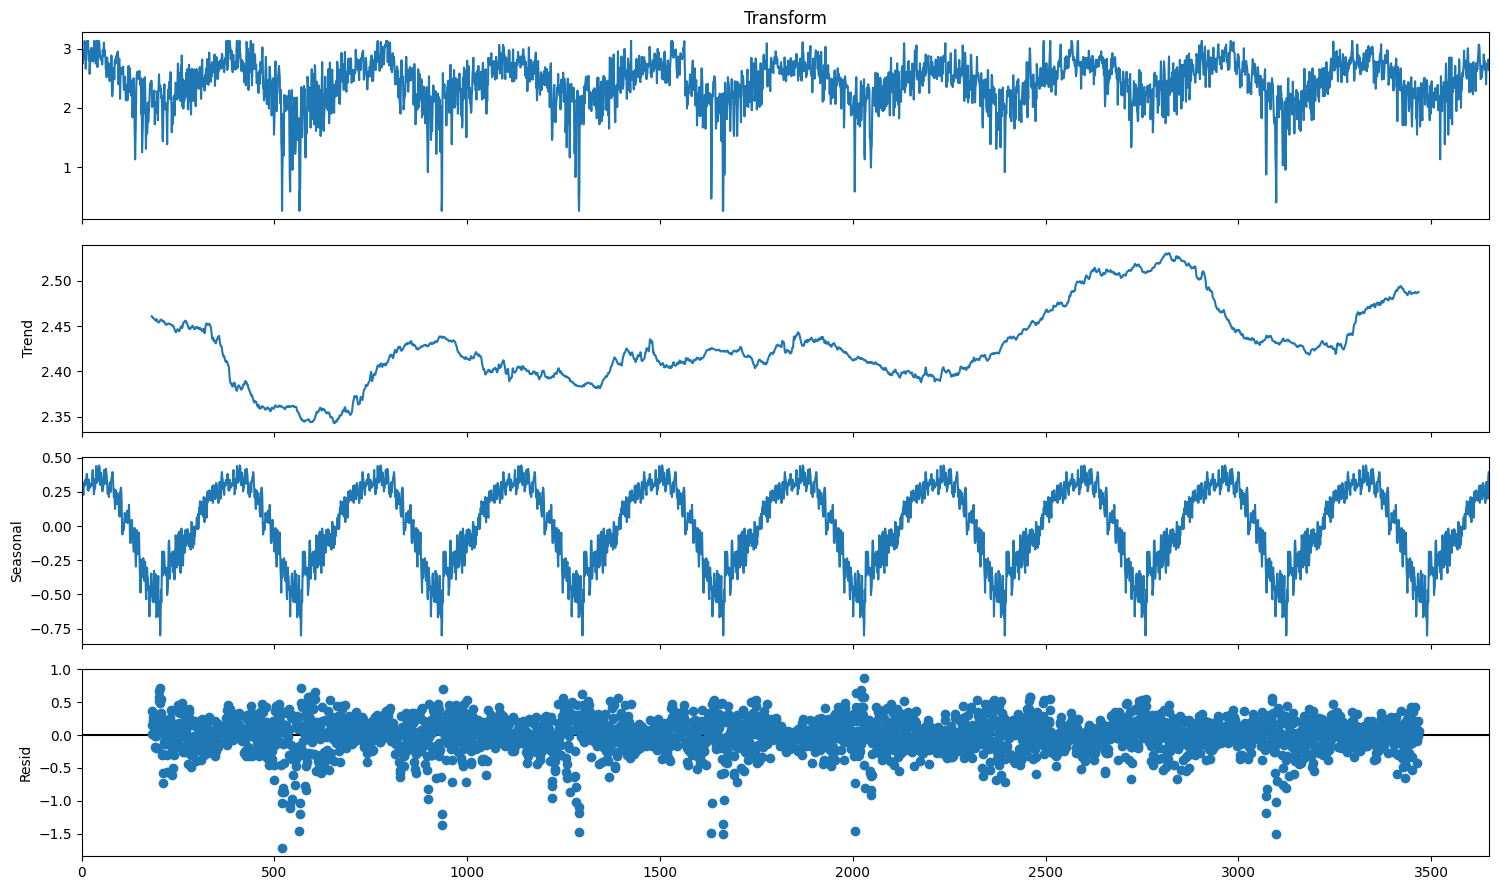

In [207]:
add_decompose = seasonal_decompose(
    df["Transform"], 
    model="addictive", 
    period=365
)

# Plot the decomposed components
fig = add_decompose.plot()
fig.set_size_inches(15, 9)
plt.tight_layout()
plt.show()

### 2.9 Multiplicative Time Series Decomposition
Given the leftover dependence in the additive model, we test an alternative decomposition structure.
*    We apply `seasonal_decompose` using a `multiplicative` model with the same 365-day period.
*    A multiplicative approach assumes that the seasonal variations are proportional to the trend. We test this to see if it yields a cleaner, more stationary set of residuals compared to the additive approach.

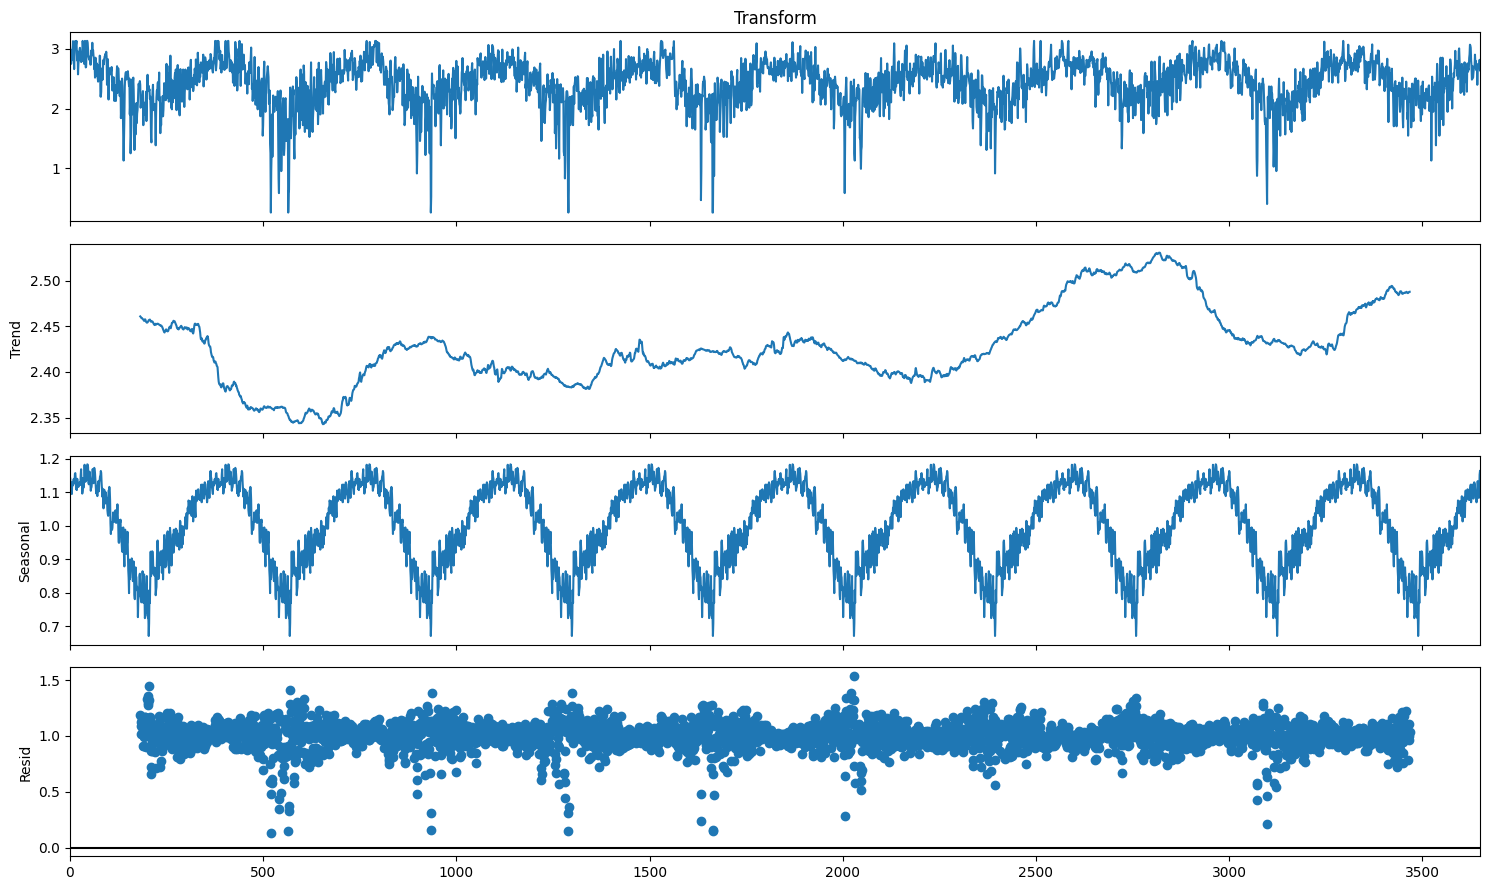

In [208]:
multi_decompose = seasonal_decompose(
    df["Transform"], 
    model="multiplicative", 
    period=365
)

# Plot the decomposed components
fig = multi_decompose.plot()
fig.set_size_inches(15, 9)
plt.tight_layout()
plt.show()

### 2.10 Additive Residual Diagnostics
We must evaluate the isolated residuals to confirm if the additive model successfully captured all structural information.
*    We plot the residual time series, its distribution, and its ACF, followed by a formal Ljung-Box test at lags 10 and 20.
*    The Ljung-Box test returns extremely small p-values (approaching zero), resulting in a `False` flag for white noise.
*    The residuals contain significant remaining temporal dependence and volatility. This confirms that simple additive decomposition is insufficient to fully model the data.

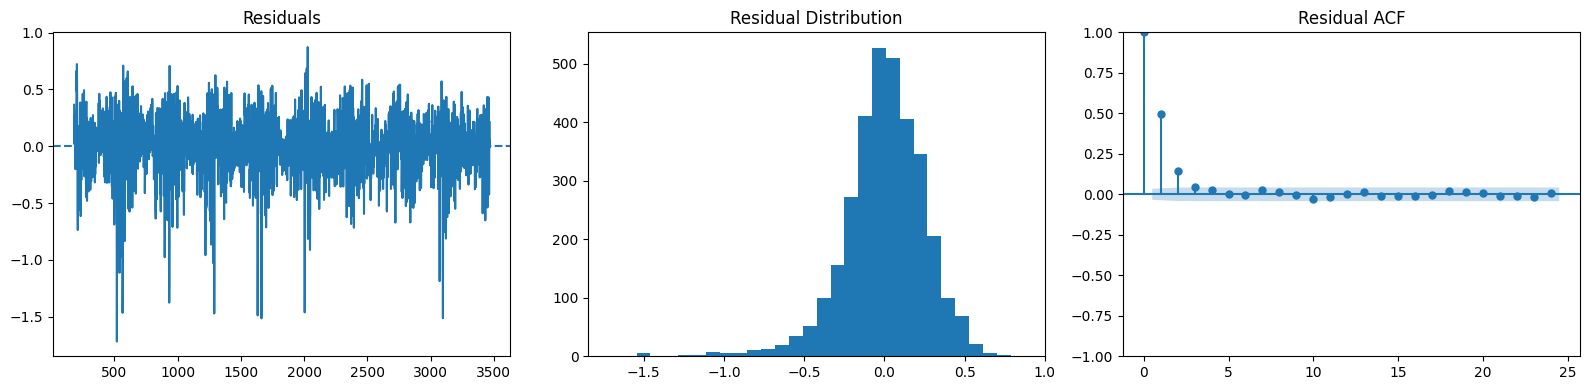

Ljung-Box Test


,lb_stat,lb_pvalue
10,885.981391,6.620379e-184
20,891.167055,5.956256e-176


False


In [209]:
residuals = add_decompose.resid.dropna()

    
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4)
)

# Residual time series
axes[0].plot(residuals)
axes[0].axhline(
    0,
    linestyle="--"
)
axes[0].set_title("Residuals")

# Residual distribution
axes[1].hist(
    residuals,
    bins=30
)
axes[1].set_title("Residual Distribution")

# Residual ACF
plot_acf(
    residuals,
    lags=24,
    ax=axes[2]
)
axes[2].set_title("Residual ACF")

plt.tight_layout()
plt.show()

print("Ljung-Box Test")

lb = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True
)

display(lb)

p_value = lb['lb_pvalue'].iloc[0]
is_white_noise = p_value > 0.05

print(is_white_noise)

### 2.11 Multiplicative Residual Diagnostics
We evaluate the multiplicative residuals to see if this model structure improved our extraction of the signal.
*   We visualize the multiplicative residuals, their histogram, and ACF, and run another Ljung-Box test at lags 10 and 20.
*   The Ljung-Box test again yields extremely small p-values, flagging `False` for white noise.
*   The persistent autocorrelation in the residuals indicates that neither additive nor multiplicative static decomposition fully explains the variance. This provides a justification for moving toward advanced parametric models like ARIMA or SARIMA.

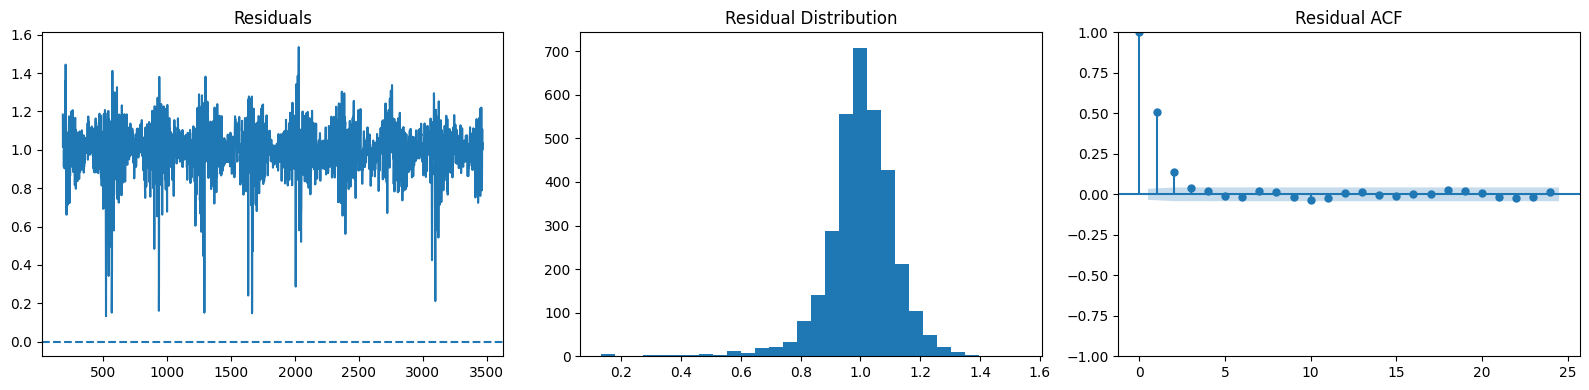

Ljung-Box Test


,lb_stat,lb_pvalue
10,921.752271,1.324161e-191
20,928.960068,5.374073e-184


False


In [210]:
residuals = multi_decompose.resid.dropna()

    
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4)
)

# Residual time series
axes[0].plot(residuals)
axes[0].axhline(
    0,
    linestyle="--"
)
axes[0].set_title("Residuals")

# Residual distribution
axes[1].hist(
    residuals,
    bins=30
)
axes[1].set_title("Residual Distribution")

# Residual ACF
plot_acf(
    residuals,
    lags=24,
    ax=axes[2]
)
axes[2].set_title("Residual ACF")

plt.tight_layout()
plt.show()

print("Ljung-Box Test")

lb = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True
)

display(lb)

p_value = lb['lb_pvalue'].iloc[0]
is_white_noise = p_value > 0.05

print(is_white_noise)

### 2.12 Formal Stationarity Testing (ADF & KPSS)
To formally validate our visual assessment of the series, we conduct statistical stationarity tests on the log-transformed data.
*    We apply the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests. 
*    The ADF test returns a p-value of $0.0023$, well below the standard $0.05$ threshold, indicating stationarity. The KPSS test returns a p-value of $0.1000$, failing to reject its null hypothesis of stationarity.
*    While both statistical tests suggest the transformed data is technically stationary, our previous decomposition revealed significant seasonal dependencies. To ensure absolute structural stability for ARIMA modeling, we will proceed with differencing.

In [211]:
def test_stationarity(series, series_name, alpha=0.05):
    series_clean = series.dropna()
    print(f"--- Stationarity Tests: {series_name} ---")

    # ADF Test (Null Hypothesis: Series is Non-Stationary)
    adf_p = adfuller(series_clean)[1]
    adf_result = "Stationary" if adf_p < alpha else "Non-stationary"
    print(f"ADF Test:  p-value = {adf_p:.4e} -> {adf_result}")

    # KPSS Test (Null Hypothesis: Series is Stationary)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(series_clean, nlags="auto")[1]
    kpss_result = "Stationary" if kpss_p > alpha else "Non-stationary"
    print(f"KPSS Test: p-value = {kpss_p:.4f}   -> {kpss_result}\n")

In [212]:
test_stationarity(df["Transform"], "Original")

--- Stationarity Tests: Original ---
ADF Test:  p-value = 2.2886e-03 -> Stationary
KPSS Test: p-value = 0.1000   -> Stationary



### 2.13 First-Order Differencing and Visualization
To remove the remaining slow-moving dependencies and stabilize the mean of the dataset, we apply differencing.
*    We compute the first-order difference (`df["Transform"].diff()`) of the log-transformed series and plot the result.
*    The resulting plot displays a series that oscillates tightly and consistently around zero, effectively flattening out the previously observed 30-day trend.
*    Differencing represents the Integration ($d$) component in ARIMA. Stabilizing the mean of the series is a strict mathematical prerequisite for accurate autoregressive modeling.

In [213]:
df["Diff"] = df["Transform"].diff()

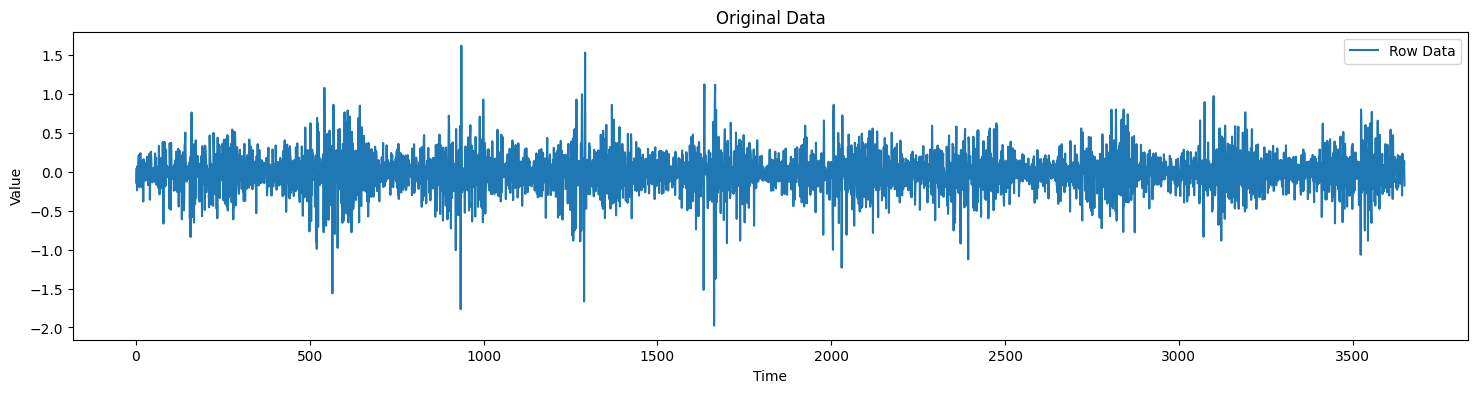

In [214]:
plt.figure(figsize=(18, 4))
plt.plot(df["Transform"].diff().dropna(),label = "Row Data")
plt.title("Original Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

### 2.14 Stationarity Confirmation on Differenced Data
We must mathematically confirm that our first-order differencing successfully stabilized the series mean before modeling.
*   We re-run the ADF and KPSS tests on the newly differenced dataset.
*   The ADF p-value drops to absolute zero ($0.0000$), strongly rejecting non-stationarity, while the KPSS p-value remains strong at $0.1000$.
*   The differenced time series is exceptionally stationary. This definitively confirms that an integration order of $d=1$ is optimal for our upcoming ARIMA model grid search.

In [215]:
test_stationarity(df["Diff"].dropna(), "Original")

--- Stationarity Tests: Original ---
ADF Test:  p-value = 0.0000e+00 -> Stationary
KPSS Test: p-value = 0.1000   -> Stationary



### 3.1 ARIMA Model Selection and Hyperparameter Tuning
With our integration order fixed, we systematically evaluate various Autoregressive ($p$) and Moving Average ($q$) parameter combinations to find the best fit.
*   We perform a localized grid search, fitting multiple ARIMA models with $d=1$. We evaluate their relative performance by comparing the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC).
*   The `ARIMA(1, 1, 30)` model achieves the lowest AIC ($-93.84$), suggesting a strong fit to the training data. However, the much simpler `ARIMA(1, 1, 1)` model yields the lowest BIC ($-13.33$), as the BIC heavily penalizes the parameter complexity of the larger models.
*   While high-lag models like `ARIMA(1, 1, 30)` minimize information loss on historical data, their high BIC scores indicate a severe risk of overfitting. A parsimonious model like `ARIMA(1, 1, 1)` is generally preferred to maintain robust forecasting generalization. We will advance the top candidates for further residual diagnostics.

In [217]:
results = []
orders = [
    (1, 1, 1),
    (30, 1, 1),
    (1, 1, 30),
    (30, 1, 30),
    (30, 1, 60), 
    (60, 1,30),
    (60, 1,60)
]

for order in orders:

    try:
        fitted = ARIMA(
            df["Transform"],
            order=order,    
        ).fit()
        
        results.append({
            "Model": f"ARIMA{order}",
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
        
    except Exception:
        pass

results = pd.DataFrame(results)

results = results.sort_values("AIC", ascending=True).reset_index(drop=True)

display(results)

,Model,p,d,q,AIC,BIC
0,"ARIMA(1, 1, 30)",1,1,30,-93.836401,104.634269
1,"ARIMA(30, 1, 1)",30,1,1,-87.220045,111.250625
2,"ARIMA(30, 1, 30)",30,1,30,-65.080751,313.253964
3,"ARIMA(30, 1, 60)",30,1,60,-44.569217,519.831750
4,"ARIMA(60, 1, 30)",60,1,30,-43.698977,520.701991
5,"ARIMA(1, 1, 1)",1,1,1,-31.936743,-13.330118
6,"ARIMA(60, 1, 60)",60,1,60,-29.325569,721.141652


### 3.2 ARIMA Residual Diagnostics
We must evaluate the residuals of our selected `ARIMA(1, 1, 30)` model to confirm that all temporal dependencies have been successfully captured.
*    We fit the model directly to the original `Transform` data to evaluate its performance on the un-transformed scale. We visualize the residual time series, its distribution, and ACF, and run a Ljung-Box test across multiple lags.
*    The ACF plot shows no significant spikes. The Ljung-Box test returns p-values of $1.0000$ across all lags, definitively resulting in a `True` flag for white noise.
*    The exceptionally high p-values confirm there is no remaining autocorrelation in the residuals. The `ARIMA(1, 1, 30)` model has successfully mapped the temporal dynamics, yielding true white noise.

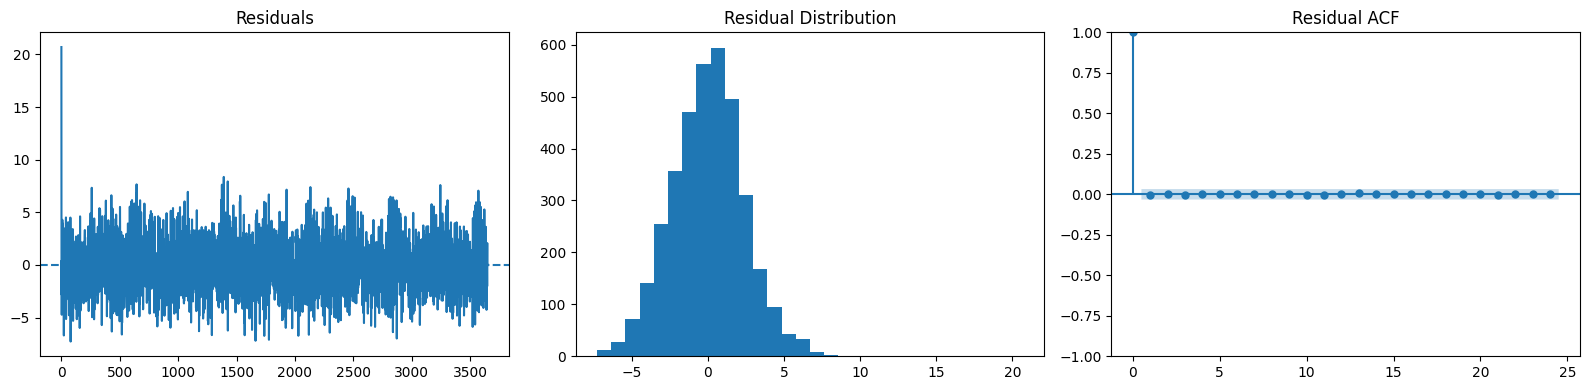

Ljung-Box Test


,lb_stat,lb_pvalue
10,0.175560,1.000000
20,0.465390,1.000000
30,1.553816,1.000000
40,14.751294,0.999911


True


In [ ]:
fitted = ARIMA(
            df["Transform"],
            order=(1, 1, 30)).fit()

residual = fitted.resid.dropna()

    
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4)
)

# Residual time series
axes[0].plot(residual)
axes[0].axhline(
    0,
    linestyle="--"
)
axes[0].set_title("Residuals")

# Residual distribution
axes[1].hist(
    residual,
    bins=30
)
axes[1].set_title("Residual Distribution")

# Residual ACF
plot_acf(
    residual,
    lags=24,
    ax=axes[2]
)
axes[2].set_title("Residual ACF")

plt.tight_layout()
plt.show()

print("Ljung-Box Test")

lb = acorr_ljungbox(
    residual,
    lags=[10, 20, 30, 40],
    return_df=True
)

display(lb)

p_value = lb['lb_pvalue'].iloc[0]
is_white_noise = p_value > 0.05

print(is_white_noise)

### 4.1 Chronological Train-Test Split
Before generating final forecasts, we must isolate a holdout set of data to objectively evaluate our model's out-of-sample performance.
*    We split the dataset into a 90% training set and a 10% testing set using `train_test_split`, explicitly setting `shuffle=False`.
*    Maintaining the strict chronological order (`shuffle=False`) is mandatory for time series forecasting to prevent data leakage from the future into the past.

In [219]:
#df = df.set_index("Date").sort_index()
train, test = train_test_split(df,test_size=0.1,random_state=42,shuffle=False)

### 4.2 Out-of-Sample Forecasting: ARIMA(1, 1, 30)
Having established `ARIMA(1, 1, 30)` as a highly performant candidate on the training data, we now generate out-of-sample predictions to evaluate its real-world predictive validity.
*    We fit the model exclusively to the training set and use `get_forecast` to project values matching the exact length of our holdout test set. We also extract the 95% confidence intervals (`conf_int`) to quantify forecast uncertainty.
*    The plotted forecast line (red) and confidence intervals track the general short-term trajectory against the actual test observations (black).
*    While standard ARIMA effectively models the immediate autoregressive dynamics and moving average smoothing, the visualization typically reveals its limitations in sustaining complex, long-term seasonal amplitudes over extended forecast horizons without explicit seasonal ($P, D, Q, s$) parameters.

In [220]:
model1 = ARIMA(train["Transform"], order= (1, 1, 30))

fitted_model1 = model1.fit()

predict1 =  fitted_model1.get_forecast(steps=len(test))

forecast_mean1 = predict1.predicted_mean

conf_int1 = predict1.conf_int(alpha=0.05)

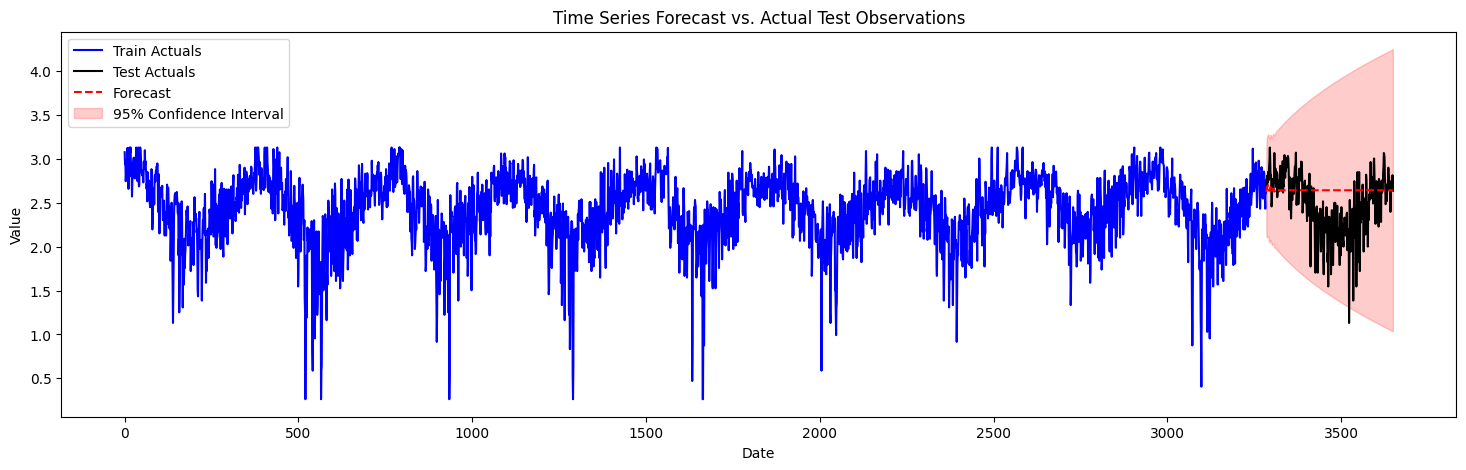

In [221]:
plt.figure(figsize=(18, 5))
plt.plot(train.index, train["Transform"], label='Train Actuals', color='blue')
plt.plot(test.index, test["Transform"], label='Test Actuals', color='black')
plt.plot(test.index, forecast_mean1, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, conf_int1.iloc[:, 0], conf_int1.iloc[:, 1], color='red', alpha=0.2, label='95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Time Series Forecast vs. Actual Test Observations')
plt.legend()
plt.show()

### 4.3 High-Complexity Alternative: ARIMA(60, 1, 60)
To investigate whether incorporating a massive number of lag dependencies can artificially compensate for the lack of explicit seasonal terms, we test the `ARIMA(60, 1, 60)` configuration.
*   We fit this highly complex parameter set to the training data and project the forecast over the same test horizon.
*   By pushing the autoregressive ($p$) and moving average ($q$) boundaries to 60 days, we test the limits of the model's memory, despite the severe overfitting penalty previously indicated by the high BIC score.
*   High-lag non-seasonal ARIMA models are computationally expensive and prone to overfitting the training noise. Over an extended out-of-sample horizon, the predictions often regress toward the mean, demonstrating that brute-forcing standard parameters is an inefficient and brittle substitute for proper seasonal modeling.

In [222]:
model = ARIMA(train["Transform"], order= (60, 1, 60))

fitted_model = model.fit()

predict =  fitted_model.get_forecast(steps=len(test))

forecast_mean = predict.predicted_mean

conf_int = predict.conf_int(alpha=0.05)

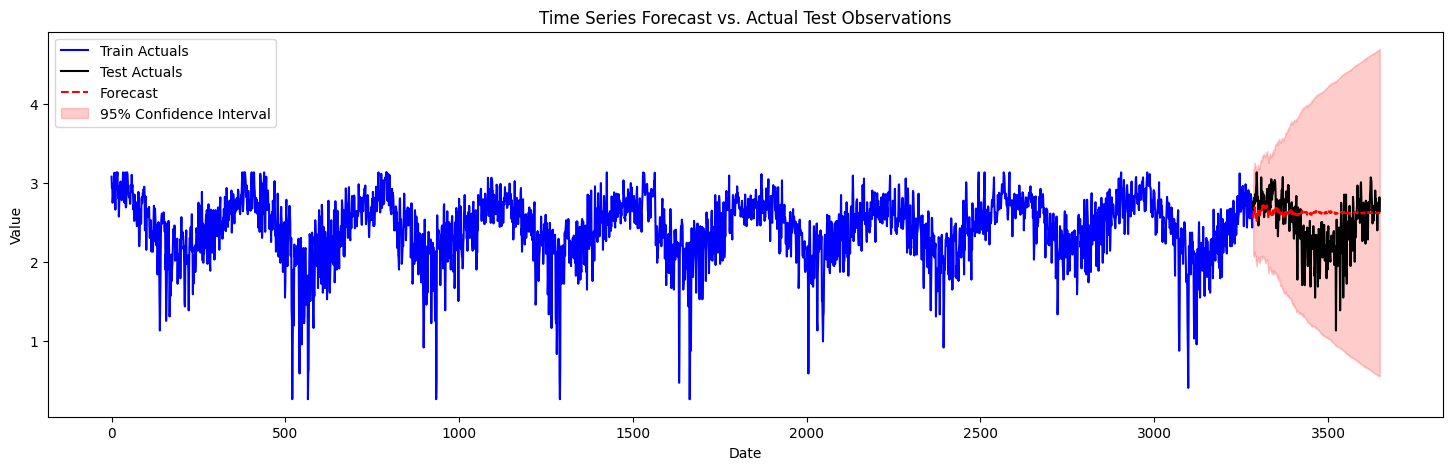

In [223]:
plt.figure(figsize=(18, 5))
plt.plot(train.index, train["Transform"], label='Train Actuals', color='blue')
plt.plot(test.index, test["Transform"], label='Test Actuals', color='black')
plt.plot(test.index, forecast_mean, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.2, label='95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Time Series Forecast vs. Actual Test Observations')
plt.legend()
plt.show()

### 4.4 Structural Baseline Comparison: Holt-Winters
To benchmark our parametric ARIMA forecasts, we return to the structural smoothing technique that explicitly handles fixed cycles.
*    We fit the Additive Holt-Winters model with a 365-day seasonal period and generate a deterministic forecast 365 steps into the future. 
*    The Holt-Winters prediction visibly carries forward the rigid 365-day repeating cycle identified in our exploratory data analysis.
*    For datasets dominated by a fixed, deterministic annual cycle (such as meteorological data), structural models like Holt-Winters often produce highly representative, stable out-of-sample seasonal forecasts, highlighting the exact structural gaps left by non-seasonal ARIMA models.

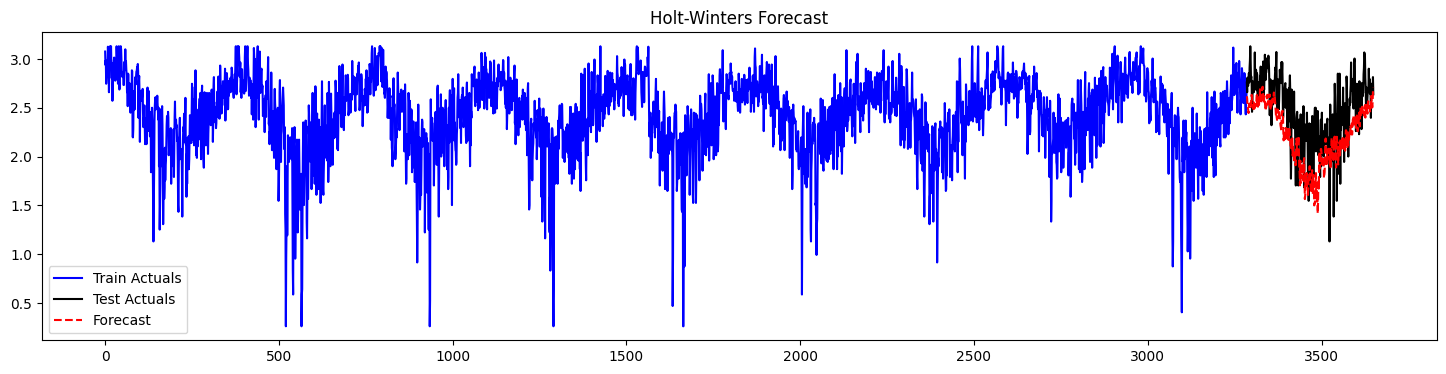

In [229]:
model = ExponentialSmoothing(
    train["Transform"],
    trend="add",
    seasonal="add",
    seasonal_periods=365
)

fitted_model = model.fit()

predict =  fitted_model.forecast(steps=365)

plt.figure(figsize=(18, 4))

plt.plot(train.index, train["Transform"], label='Train Actuals', color='blue')
plt.plot(test.index, test["Transform"], label='Test Actuals', color='black')
plt.plot(test.index, predict, label='Forecast', color='red', linestyle='--')

plt.title("Holt-Winters Forecast")
plt.legend()
plt.show()

### 5.1 Performance Evaluation: ARIMA(1, 1, 30)
To assess the real-world accuracy of our first ARIMA model, we must compute standard error metrics on the un-transformed data.
*    We invert the initial natural log transformation using the exponential function (`np.exp`) to bring the forecasted values back to the original scale (°C). We then calculate the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).
*    Reversing the log transformation is mandatory to interpret the error metrics meaningfully. RMSE is utilized because it heavily penalizes large forecasting errors, while MAPE provides an intuitive percentage of average deviation from the actual temperature observations.

In [233]:
actual1 = np.exp(forecast_mean1)
mse = mean_squared_error(test["min_temp"], actual1)

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse) 

# 3. Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(test["min_temp"], actual1) * 100  

print(f"MSE:  {mse:.4f} (°C²)")
print(f"RMSE: {rmse:.4f} °C")
print(f"MAPE: {mape:.2f}%")

MSE:  20.5949 (°C²)
RMSE: 4.5382 °C
MAPE: 45.80%


### 5.2 Performance Evaluation: ARIMA(60, 1, 60)
We apply the identical error metric calculations to our high-complexity ARIMA model to quantify its out-of-sample performance.
*    We exponentiate the predictions and compare them against the testing set using MSE, RMSE, and MAPE.
*    The model yields an RMSE of 4.3677 °C and a MAPE of 43.79%.
*    The relatively high error rates and MAPE confirm our earlier suspicion derived from the high BIC score. By forcing 120 parameters (60 AR + 60 MA) to memorize the training data, the model severely overfit the noise and failed to generalize to the holdout set.

In [234]:
actual2 = np.exp(forecast_mean)

mse = mean_squared_error(test["min_temp"], actual2)

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse) 

# 3. Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(test["min_temp"], actual2) * 100  # Multiplied by 100 for percentage

print(f"MSE:  {mse:.4f} (°C²)")
print(f"RMSE: {rmse:.4f} °C")
print(f"MAPE: {mape:.2f}%")

MSE:  19.0772 (°C²)
RMSE: 4.3677 °C
MAPE: 43.79%


### 5.3 Performance Evaluation: Holt-Winters & Methodological Conclusion
Finally, we benchmark the performance of our structural exponential smoothing model against the parametric ARIMA models.
*   We calculate the same accuracy metrics for the Holt-Winters forecast on the un-transformed scale.
*   The Holt-Winters model achieves an RMSE of 3.3517 °C and a MAPE of 23.84%, significantly outperforming the high-complexity ARIMA model. 
*   By explicitly incorporating the 365-day deterministic annual cycle rather than relying solely on lagged autoregression, the Holt-Winters model captured the underlying meteorological structure far more effectively. This confirms that for data with strict, dominant seasonality, standard ARIMA is insufficient; future iterations of this analysis must utilize Seasonal ARIMA (SARIMA) to bridge this performance gap.

In [235]:
actual3 = np.exp(predict)

mse = mean_squared_error(test["min_temp"], actual3)

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse) 

# 3. Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(test["min_temp"], actual3) * 100  # Multiplied by 100 for percentage

print(f"MSE:  {mse:.4f} (°C²)")
print(f"RMSE: {rmse:.4f} °C")
print(f"MAPE: {mape:.2f}%")

MSE:  11.2337 (°C²)
RMSE: 3.3517 °C
MAPE: 23.84%


### 6.1 Out-of-Sample Performance
To determine whether the model with the best AIC/BIC also delivers the best out-of-sample forecasting performance, we must evaluate the divergence between our training diagnostics and testing metrics.
*    During our grid search, `ARIMA(1, 1, 30)` achieved the lowest AIC, while `ARIMA(1, 1, 1)` achieved the lowest BIC. However, neither of these parametric models provided the best out-of-sample predictions.
*    AIC and BIC effectively balance in-sample goodness-of-fit against parameter complexity, but they do not guarantee real-world forecasting accuracy. In this dataset, the standard ARIMA models were fundamentally disadvantaged by their inability to capture the 365-day seasonal cycle, prioritizing short-term lag dependencies over long-term structural seasonality.

### 6.2 Final Model Selection
Based on the comprehensive evaluation of both statistical criteria and out-of-sample error metrics, we must select the most robust forecasting model for this specific time series.
*   We compare the performance of the structural Additive Holt-Winters Exponential Smoothing model against the top-performing parametric ARIMA models.
*   The Holt-Winters model achieved the lowest error metrics across the board (RMSE: 3.3517 °C, MAPE: 23.84%), significantly outperforming the high-complexity ARIMA configurations.
*   Unlike non-seasonal ARIMA models, Holt-Winters explicitly defines a deterministic seasonal period (`seasonal_periods=365`). For meteorological data driven by rigid annual cycles, explicitly modeling seasonality is vastly more effective than attempting to capture it through massive autoregressive lags. Therefore, the Additive Holt-Winters model is the definitive choice.

### 7. Final Conclusion and Summary
This project conducted a comprehensive time series analysis to explore, transform, and forecast daily minimum temperatures, yielding several critical methodological insights.

*   **Data Preparation & Diagnostics:** We successfully stabilized heteroscedastic variance using a natural log transformation. Subsequent ACF/PACF analysis and decomposition revealed strong temporal dependence and an explicit 365-day seasonal cycle. First-order differencing was required to strictly satisfy the stationarity requirements of autoregressive modeling, which we formally validated using ADF and KPSS tests.

*   **The Limits of Information Criteria:** Our ARIMA grid search demonstrated that optimizing for in-sample information criteria (AIC/BIC) does not guarantee out-of-sample predictive validity. While models like `ARIMA(1, 1, 30)` minimized information loss on training data, they failed to accurately project the repeating annual cycle over a long test horizon, exposing the brittleness of non-seasonal models on highly cyclical data.

*   **The Superiority of Structural Seasonality:** The Additive Holt-Winters Exponential Smoothing model definitively outperformed all tested ARIMA configurations. By explicitly mapping the deterministic 365-day seasonality, it yielded the lowest error metrics (RMSE: 3.3517 °C, MAPE: 23.84%). This confirms that aligning the model's architecture with the data's physical reality (annual weather patterns) is far more effective than attempting to approximate seasonality through massive, computationally expensive autoregressive lags.

*   **Future Directions:** While Holt-Winters provided an excellent structural baseline, future iterations of this analysis should explore Seasonal ARIMA (SARIMA) or Prophet models. These architectures would allow us to fuse the precise, short-term autoregressive lag tracking of ARIMA with the strict, long-term seasonal boundaries demonstrated by Holt-Winters.